# 📈 Lab 5.0 — Regression Problem
## Predicting Sleep Duration | Artificial Intelligence 5.0
---
**Problem:** Predict how many hours a person sleeps (continuous value)  
**Algorithm:** Linear Regression  
**Dataset:** Sleep Health and Lifestyle Dataset


## 1️⃣ Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")
print("✅ Libraries imported!")

✅ Libraries imported!


## 2️⃣ Load Dataset

In [35]:
# ── UPDATE THIS PATH ─────────────────────────────────────────────────────
CSV_PATH = r"C:\Users\markl\ARDUINO-TEAM_SINCO\p1classification_model\regress\sleep\Sleep_health_and_lifestyle_dataset.csv"
# ─────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 3️⃣ Handle Missing Values

In [36]:
print("Missing values per column:")
print(df.isnull().sum())

# Fill missing Sleep Disorder with "None"
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
print("✅ Missing values handled!")

Missing values per column:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64
✅ Missing values handled!


## 4️⃣ Feature Selection & Encoding

In [37]:
# Split Blood Pressure into two numeric columns
df[["BP_Systolic", "BP_Diastolic"]] = (
    df["Blood Pressure"].str.split("/", expand=True).astype(int)
)

# Drop non-feature columns
df = df.drop(columns=["Person ID", "Blood Pressure"])

# One-hot encode categorical columns
df_encoded = pd.get_dummies(
    df,
    columns=["Gender", "Occupation", "BMI Category", "Sleep Disorder"],
    drop_first=True
)

print(f"Features after encoding: {df_encoded.shape[1] - 1}")
df_encoded.head()

Features after encoding: 24


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,BP_Systolic,BP_Diastolic,Gender_Male,...,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_None,Sleep Disorder_Sleep Apnea
0,27,6.1,6,42,6,77,4200,126,83,True,...,False,False,False,True,False,False,False,True,True,False
1,28,6.2,6,60,8,75,10000,125,80,True,...,False,False,False,False,False,False,False,False,True,False
2,28,6.2,6,60,8,75,10000,125,80,True,...,False,False,False,False,False,False,False,False,True,False
3,28,5.9,4,30,8,85,3000,140,90,True,...,True,False,False,False,False,False,True,False,False,True
4,28,5.9,4,30,8,85,3000,140,90,True,...,True,False,False,False,False,False,True,False,False,True


## 5️⃣ Split Dataset into Training and Testing Sets

In [38]:
X = df_encoded.drop(columns=["Sleep Duration"])
y = df_encoded["Sleep Duration"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 299
Testing  samples : 75


## 6️⃣ Scale Features

In [39]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("✅ Features scaled!")

✅ Features scaled!


## 7️⃣ Build & Train the Model

In [40]:
model = LinearRegression()
model.fit(X_train_sc, y_train)
print("✅ Linear Regression model trained!")

✅ Linear Regression model trained!


## 8️⃣ Evaluate the Model

In [41]:
y_pred = model.predict(X_test_sc)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=== Regression Metrics ===")
print(f"MAE  : {mae:.4f} hours")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f} hours")
print(f"R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")

=== Regression Metrics ===
MAE  : 0.2064 hours
MSE  : 0.0743
RMSE : 0.2726 hours
R²   : 0.8883  (88.8% variance explained)


## 9️⃣ Visualize Results

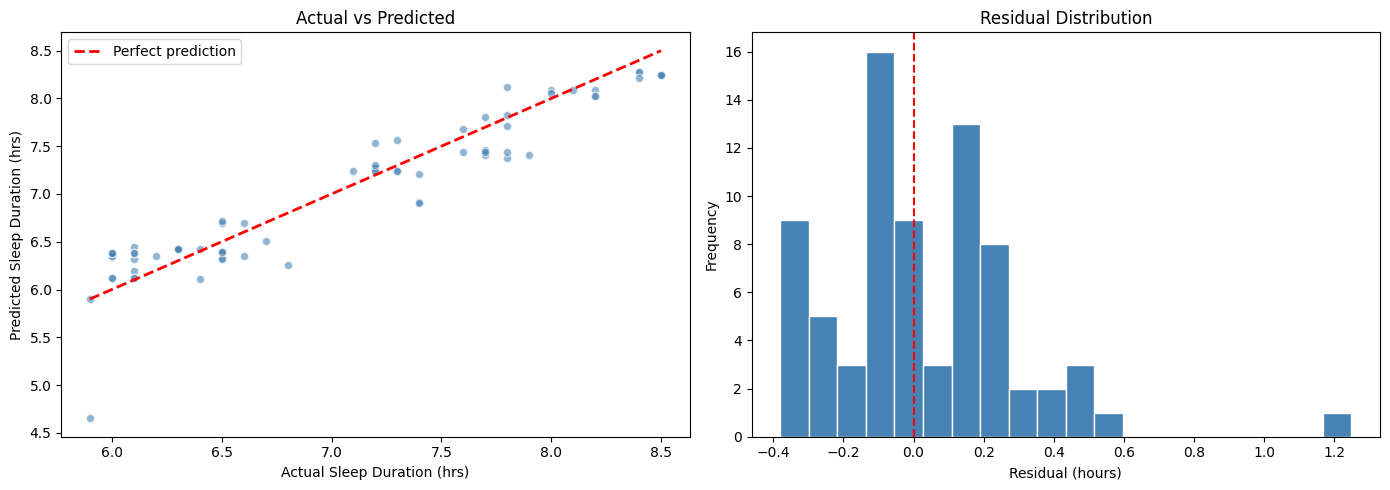

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color="steelblue", edgecolors="white")
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Sleep Duration (hrs)")
axes[0].set_ylabel("Predicted Sleep Duration (hrs)")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=20, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (hours)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

Feature Coefficients

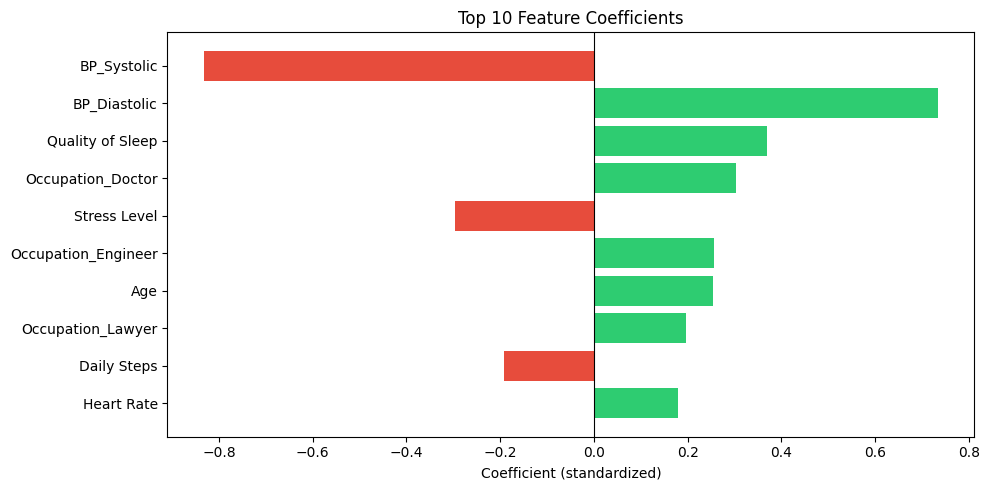

            Feature  Coefficient
        BP_Systolic    -0.831525
       BP_Diastolic     0.733344
   Quality of Sleep     0.368557
  Occupation_Doctor     0.303955
       Stress Level    -0.297062
Occupation_Engineer     0.257222
                Age     0.253793
  Occupation_Lawyer     0.197200
        Daily Steps    -0.191769
         Heart Rate     0.178903


In [43]:
coef_df = (
    pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    .assign(Abs=lambda d: d["Coefficient"].abs())
    .sort_values("Abs", ascending=False)
    .head(10)
)

colors = ["#2ECC71" if c > 0 else "#E74C3C" for c in coef_df["Coefficient"]]

plt.figure(figsize=(10, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (standardized)")
plt.title("Top 10 Feature Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(coef_df[["Feature", "Coefficient"]].to_string(index=False))

In [44]:
print(f"Model Accuracy (R²): {r2*100:.2f}%")


Model Accuracy (R²): 88.83%


---
## ✅ Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **MAE** | ~0.21 hrs | Avg error of ~12 minutes |
| **MSE** | ~0.07 | Squared error |
| **RMSE** | ~0.27 hrs | ~16 minutes typical error |
| **R²** | ~0.888 | Model explains 88.8% of variance |

*Lab 5.0 — Artificial Intelligence | rgj*
